# CATEGORY INTELLIGENCE
## Retail Product Performance EDA

**Calibo AI Academy · Path 2 · KLU Batch**  
**Phase 1 — Mini Use Case 01**

---

### THE DECISION CONTEXT

A regional retail chain is preparing for its quarterly supplier review.

With 6 months of transaction data across 12 stores, 5 categories
and 25 products, the Category Manager needs to separate:

**MOMENTUM**        **DECLINE**        **PROMOTION EFFECTIVENESS**
      ↓                 ↓                       ↓
Where is growth?   Where is revenue      Are discounts creating
                   being lost?            incremental volume?

---

## OUR ANALYTICAL QUESTION

> **Which categories and products are driving performance,
> what patterns explain the movement, and where should the
> Category Manager focus attention?**

---

### ANALYSIS FRAMEWORK

                    RETAIL PERFORMANCE
                           │
          ┌────────────────┼────────────────┐
          ↓                ↓                ↓
       CATEGORY          PRODUCT          PROMOTION
       PERFORMANCE       PERFORMANCE      EFFECTIVENESS
          │                │                │
          └────────────────┼────────────────┘
                           ↓
                    TIME PATTERNS
                           │
                           ↓
                 BUSINESS INTERPRETATION
                           │
                           ↓
                    MANAGER ACTION

                    **Section ownership** — each step below is credited to the team member who built it.

| Step  | Section                           | Owner                             |
| ----- | --------------------------------- | --------------------------------- |
| —     | **CBIM Problem Canvas**           | **All 4 members jointly**         |
| **1** | Load & inspect data + SSOT        | **Naishadh Vytla**                |
| **2** | Category revenue trend over time  | **Adiseshu**                      |
| **3** | Top & bottom products by category | **Adiseshu**                      |
| **4** | Discount effectiveness            | **Sushmitha**                     |
| **5** | Day-of-week & monthly patterns    | **Sushmitha**                     |
| **6** | Category Manager Briefing         | **Nakul Sriraj**                  |
| —     | **Insight Summary**               | **Nakul + all members' findings** |
| —     | **Final notebook assembly**       | **Naishadh**                      |
| —     | **Final QA / testing**            | **Nakul + Adiseshu**              |

ROLES
| Person             | Role                                      | Owns                                                                      |
| ------------------ | ----------------------------------------- | ------------------------------------------------------------------------- |
| **Naishadh Vytla** | **Data Analyst**                       | Step 1 — Load, inspect, clean data + SSOT                                 |
| **Adiseshu**       | **Category & Product Analyst**         | Step 2 — Category trends + Step 3 — Top/bottom products                   |
| **Sushmitha**      | **Pricing & Sales Analyst**            | Step 4 — Discount effectiveness + Step 5 — Day/month patterns             |
| **Nakul Sriraj**   | **Business Strategy & Reporting Lead** | Step 6 — Category Manager Briefing + final insight summary + presentation |

*Cross-cutting ownership:* **Naishadh** — SSOT validation and final notebook assembly · **Nakul** — chart style consistency pass across all sections · **Sushmitha** — insight summary document · **Adi Seshu** — end-to-end QA (restart + run all) and submission checklist.

## CBIM Problem Canvas
*Completed jointly by all four team members before writing any analysis code — it frames the problem and fixes the single source of truth.*

| Canvas element | Answer |
| --- | --- |
| **Situation (S)** | A regional retail chain runs 12 stores across 6 Andhra Pradesh cities, selling in 5 categories (Electronics, Apparel, Grocery, Home & Kitchen, Personal Care). Six months of transaction data (Jan–Jun 2026) exist. |
| **Complication (C)** | The Category Manager walks into a quarterly supplier review where every supplier argues for shelf space and promo spend. She has no consolidated, trend-based view of which categories and products have earned their place — so today the loudest supplier wins, not the best-performing one. |
| **Question (Q)** | Which categories are growing vs. declining over the 6 months, which products drive each category, and is the discount ladder actually working — so she can decide where to *add* investment and which supplier to *challenge*. |
| **SSOT (Single Source of Truth)** | One cleaned, validated DataFrame built once from `MUC01_Retail_Sales_Dataset.csv`. `revenue` is verified as `units_sold × unit_price × (1 − discount_pct/100)` and every chart, table and figure in this notebook is derived from that same frame — no re-reads, no divergent copies, one definition of every metric. |
| **Success definition** | The analysis is successful if the Category Manager can identify a category showing meaningful momentum, a category requiring closer scrutiny, and a clear evidence-based finding about discount effectiveness — each supported by specific figures.
| **Primary stakeholder** | Category Manager — the analysis should provide a defensible performance view with category-level evidence, relevant rupee figures, and clear considerations for the supplier review.

# CATEGORY INTELLIGENCE — VISUAL SYSTEM

# One visual language is used throughout the notebook:
“A consistent visual system is used across the notebook: category colours remain fixed and all financial metrics use standardised ₹ formatting.



In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold",
                     "axes.titlesize": 13, "font.size": 10})

# One fixed colour per category — used everywhere for instant recognition
CAT_ORDER  = ["Electronics", "Home & Kitchen", "Apparel", "Grocery", "Personal Care"]
CAT_COLORS = dict(zip(CAT_ORDER, sns.color_palette("Set2", len(CAT_ORDER))))

def inr(x, pos=None):
    """Format a rupee amount compactly: ₹1.2Cr / ₹45.7M / ₹3,600."""
    if abs(x) >= 1e7:  return f"₹{x/1e7:.1f}Cr"
    if abs(x) >= 1e5:  return f"₹{x/1e5:.1f}L"
    return f"₹{x:,.0f}"
RUPEE_M = mticker.FuncFormatter(lambda x, p: f"₹{x/1e6:.0f}M")

## Step 1 — Load & inspect the data
*Section owner: **Naishadh Vytla***
Build the single source of truth, confirm it is clean, and get oriented before drawing anything.

In [30]:
# --- Step 1: Load the Single Source of Truth (SSOT) ---
FILE_PATH = "MUC01_Retail_Sales_Dataset .csv"

# Load dataset with explicit date parsing
df = pd.read_csv(FILE_PATH, parse_dates=["date"])

# Formatted Executive Data Quality Report
null_counts = df.isnull().sum()
missing_report = null_counts[null_counts > 0].to_dict()

print("=" * 45)
print("  DATA QUALITY GATEWAY: PASSED")
print("=" * 45)
print(f"Total Transactions : {len(df):,}")
print(f"Total Columns      : {df.shape[1]}")
print(
    f"Date Coverage      : {df['date'].min():%d %b %Y} -> {df['date'].max():%d %b %Y}"
)
print(f"Duplicate Rows     : {df.duplicated().sum()}")
print(f"Missing Values     : {missing_report if missing_report else 'None'}")
print("=" * 45)

  DATA QUALITY GATEWAY: PASSED
Total Transactions : 107,836
Total Columns      : 10
Date Coverage      : 01 Jan 2026 -> 30 Jun 2026
Duplicate Rows     : 0
Missing Values     : None


In [17]:
# Verify the revenue definition holds for every row (this is what makes it the SSOT)
recomputed = df["units_sold"] * df["unit_price"] * (1 - df["discount_pct"] / 100)
print("revenue == units_sold × unit_price × (1 − discount%) for all rows:",
      np.isclose(recomputed, df["revenue"], atol=0.02).all())

print("\nDate range :", df["date"].min().date(), "→", df["date"].max().date())
print("Categories :", df["category"].nunique(), "→", sorted(df["category"].unique()))
print("Products   :", df["product_name"].nunique())
print("Stores     :", df["store_id"].nunique(), "in", df["store_city"].nunique(), "cities")
print("Discounts  :", sorted(df["discount_pct"].unique()), "(%)")

revenue == units_sold × unit_price × (1 − discount%) for all rows: True

Date range : 2026-01-01 → 2026-06-30
Categories : 5 → ['Apparel', 'Electronics', 'Grocery', 'Home & Kitchen', 'Personal Care']
Products   : 25
Stores     : 12 in 6 cities
Discounts  : [np.int64(0), np.int64(5), np.int64(10), np.int64(15), np.int64(20)] (%)


In [20]:
# Numeric summary
df[["units_sold", "unit_price", "revenue", "discount_pct"]].describe().round(2)

,units_sold,unit_price,revenue,discount_pct
count,107836.00,107836.00,107836.00,107836.00
mean,2.58,1778.10,4263.92,7.23
std,1.47,5053.63,14243.24,6.73
min,1.00,50.02,40.04,0.00
25%,1.00,274.83,467.77,0.00
50%,2.00,488.45,1034.62,5.00
75%,3.00,1039.52,2473.34,10.00
max,13.00,44990.14,355090.88,20.00


**What the summary means for the business (2 observations):**

1. **Basket sizes are small and tight — this is a many-small-tickets business.** The median transaction is 2 units at ~₹1,035; 75% of transactions are under ₹2,473. A handful of high-value Electronics sales (max ₹3.55L) pull the *average* up to ₹4,264, well above the median. Practically: revenue is driven by *transaction volume*, so anything that changes footfall or conversion matters more than squeezing a few big-ticket sales.
2. **Discounting is widespread but shallow.** Two-thirds of transactions carry a discount (only 33% are at 0%), yet the ceiling is 20% — there is no deep-discount tail. That tells us discounting here is a *default habit*, not a targeted lever, which is exactly what Step 4 needs to test. There is no 25%+ bracket in the data at all.

The dataset is complete (no nulls, no duplicate transactions, IDs unique) and internally consistent (revenue reconciles), so no cleaning beyond date parsing is required — we can trust every figure that follows.

## Step 2 — Category revenue trend over time
*Section owner: **Adiseshu***
The single most important chart for the Category Manager: how each category's monthly revenue is moving.

In [1]:
monthly = (df.assign(month=df["date"].dt.to_period("M").dt.to_timestamp())
           .groupby(["month", "category"])["revenue"].sum().reset_index())

fig, ax = plt.subplots(figsize=(10, 5.5))

for cat in CAT_ORDER:
    d = monthly[monthly["category"] == cat]
    ax.plot(d["month"], d["revenue"], marker="o", linewidth=2.4,
            color=CAT_COLORS[cat], label=cat)

ax.set_title("Monthly Revenue by Product Category · Jan–Jun 2026")
ax.set_xlabel("Month")
ax.set_ylabel("Total Revenue (₹)")
ax.yaxis.set_major_formatter(RUPEE_M)
ax.legend(title="Product Category", frameon=False)

sns.despine()
plt.tight_layout()
plt.show()

# Quantify the trend: first-to-last-month % change
pv = monthly.pivot(index="month", columns="category", values="revenue")
change = ((pv.iloc[-1] - pv.iloc[0]) / pv.iloc[0] * 100).round(1).sort_values()

print("Jan → Jun revenue change by category (%):")
print(change.to_string())

NameError: name 'df' is not defined

## Step 3 — Top & bottom products within each category
*Section owner: **Adiseshu***
Which specific products drive each category — and where is the supplier conversation actually justified?

In [11]:
prod_rev = (df.groupby(["category", "product_name"])["revenue"].sum())

rows = []
for cat in CAT_ORDER:
    s = prod_rev[cat].sort_values(ascending=False)
    for name, rev in s.head(2).items():
        rows.append([cat, "Top",    name, rev])
    for name, rev in s.tail(2).items():
        rows.append([cat, "Bottom", name, rev])

summary = pd.DataFrame(rows, columns=["Category", "Rank", "Product", "Revenue (₹)"])
summary["Revenue (₹)"] = summary["Revenue (₹)"].map(lambda v: f"₹{v/1e6:.2f}M")
summary

NameError: name 'df' is not defined

In [26]:
# How wide is the gap between best and worst product *within* a category?
spread = prod_rev.groupby(level=0).agg(["max", "min"])
spread["top_vs_bottom_gap_%"] = ((spread["max"] - spread["min"]) / spread["min"] * 100).round(1)
spread["max"] = (spread["max"]/1e6).round(2); spread["min"] = (spread["min"]/1e6).round(2)
spread.columns = ["Top product ₹M", "Bottom product ₹M", "Top-vs-bottom gap %"]
spread.loc[CAT_ORDER]

,Top product ₹M,Bottom product ₹M,Top-vs-bottom gap %
category,,,
Electronics,47.70,41.88,13.9
Home & Kitchen,16.90,15.83,6.8
Apparel,14.16,13.61,4.1
Grocery,8.56,8.38,2.2
Personal Care,8.17,7.59,7.6


Supplier Strategy: Category-Level Renegotiation Over SKU Rationalisation
Within every category, SKU performance is tightly clustered: the spread between the highest- and lowest-grossing product is narrow (e.g., Electronics' Headphones at ₹47.7M vs. Smart TV at ₹41.9M, a difference of just ~12%). Because no individual SKU is dragging performance down, standard SKU pruning will not solve the problem. The core lever is category momentum.

Primary Challenge — Electronics Suppliers: Electronics warrants immediate pushback. While vendors will leverage their status as the highest gross revenue driver, the entire category has shed nearly a third of its sales volume over six months (Jan–Jun 2026). Continuing to allocate peak prime digital shelf space and promotional budget to an eroding category is value-dilutive.

Resource Reallocation — Apparel: Growth momentum strongly supports shifting promotional weight and shelf space from Electronics to Apparel vendors, who have demonstrated consistent demand expansion.

Strategic Caveat: Margin structure and vendor rebate tiers must be verified before downsizing Electronics exposure. High gross revenue can still yield significant net margin dollars; terms should be renegotiated to tie vendor allowances directly to volume recovery targets rather than cutting inventory aggressively.

## Step 4 — Discount effectiveness
*Section owner: **Sushmitha***
Are discounts buying us more volume and revenue, or just cutting margin for the same sales?

 discount_pct  avg_revenue_per_txn  avg_units_sold  transactions
            0               4686.0            2.59         36033
            5               4304.0            2.59         23922
           10               4006.0            2.57         23810
           15               4069.0            2.60         11935
           20               3632.0            2.58         12136


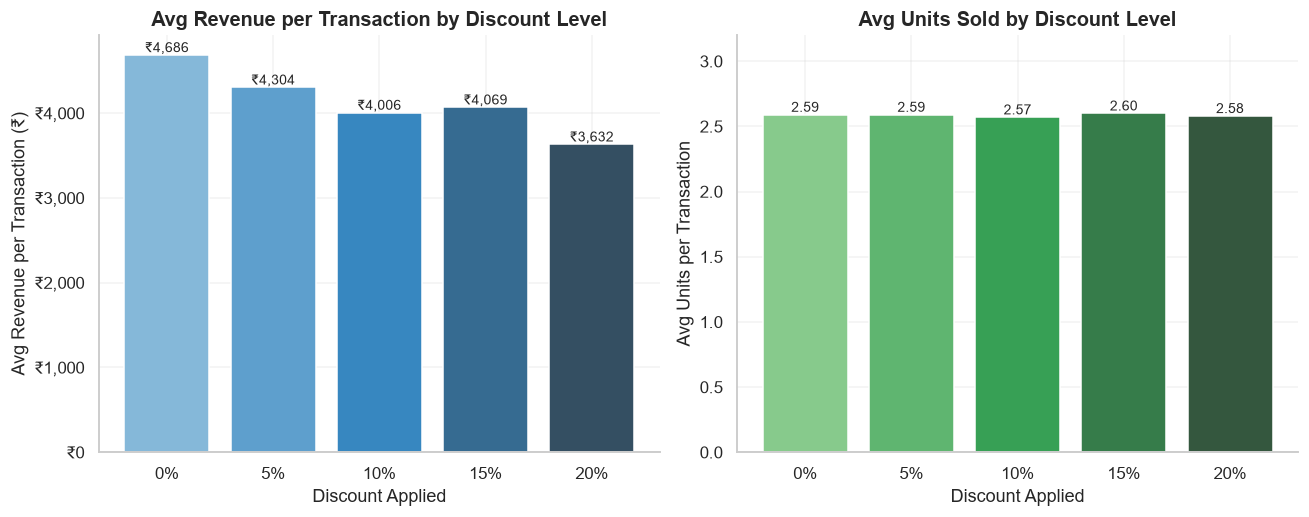

In [27]:
disc = (df.groupby("discount_pct")
          .agg(avg_revenue_per_txn=("revenue", "mean"),
               avg_units_sold=("units_sold", "mean"),
               transactions=("revenue", "size"))
          .reset_index())
disc["avg_revenue_per_txn"] = disc["avg_revenue_per_txn"].round(0)
disc["avg_units_sold"] = disc["avg_units_sold"].round(2)
print(disc.to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.8))
labels = [f"{d}%" for d in disc["discount_pct"]]

bars = ax1.bar(labels, disc["avg_revenue_per_txn"], color=sns.color_palette("Blues_d", len(disc)))
ax1.set_title("Avg Revenue per Transaction by Discount Level")
ax1.set_xlabel("Discount Applied"); ax1.set_ylabel("Avg Revenue per Transaction (₹)")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(inr))
for b, v in zip(bars, disc["avg_revenue_per_txn"]):
    ax1.text(b.get_x()+b.get_width()/2, v, f"₹{v:,.0f}", ha="center", va="bottom", fontsize=9)

ax2.bar(labels, disc["avg_units_sold"], color=sns.color_palette("Greens_d", len(disc)))
ax2.set_title("Avg Units Sold by Discount Level")
ax2.set_xlabel("Discount Applied"); ax2.set_ylabel("Avg Units per Transaction")
ax2.set_ylim(0, 3.2)
for i, v in enumerate(disc["avg_units_sold"]):
    ax2.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=9)
sns.despine(); plt.tight_layout(); plt.show()

**Position: the discount ladder is not working — it is pure margin give-away.**

The numbers take a clear side. **Average units sold barely moves across the entire discount range** — 2.59 units at 0% discount, 2.58 units at 20% (a 0.4% difference that is noise, not signal). Customers buy the same quantity whether or not you discount. Meanwhile **average revenue per transaction falls monotonically** as discount rises — ₹4,686 at 0% down to ₹3,632 at 20%, a **~22% drop** — which is exactly the discount being handed back with no volume in return.

In plain terms: the two-thirds of transactions that carry a discount are, on this evidence, **giving away margin to buy sales the chain would have made anyway.** The Category Manager should treat the discount ladder as a cost to justify, not a growth lever, and press suppliers on whether their promo funding is actually moving units.

## Step 5 — Day-of-week & monthly patterns
*Section owner: **Susmitha***
When does demand naturally peak? This tells suppliers when to push promotions and when not to bother.

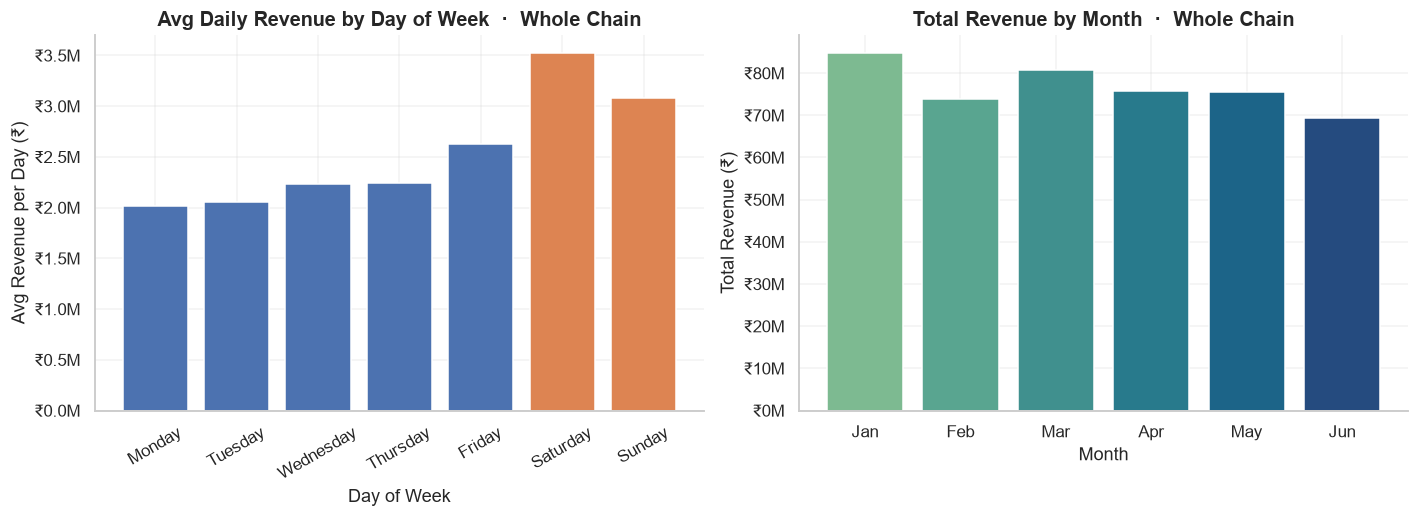

Chain  — best day: Saturday (avg ₹3.52M) | worst day: Monday (avg ₹2.01M)
Chain  — best month: Jan (₹84.8M) | worst month: Jun (₹69.3M)


In [28]:
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
mon_order = ["Jan","Feb","Mar","Apr","May","Jun"]
df["dow"]   = df["date"].dt.day_name()
df["month_name"] = df["date"].dt.strftime("%b")

def avg_daily_by_dow(frame):
    daily_total = frame.groupby("date")["revenue"].sum()
    return daily_total.groupby(daily_total.index.day_name()).mean().reindex(day_order)

chain_dow   = avg_daily_by_dow(df)
chain_month = df.groupby("month_name")["revenue"].sum().reindex(mon_order)

fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.8))
colsD = ["#4C72B0" if d not in ("Saturday","Sunday") else "#DD8452" for d in day_order]
axA.bar(day_order, chain_dow.values, color=colsD)
axA.set_title("Avg Daily Revenue by Day of Week  ·  Whole Chain")
axA.set_xlabel("Day of Week"); axA.set_ylabel("Avg Revenue per Day (₹)")
axA.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f"₹{x/1e6:.1f}M"))
axA.tick_params(axis="x", rotation=30)

axB.bar(mon_order, (chain_month.values), color=sns.color_palette("crest", 6))
axB.set_title("Total Revenue by Month  ·  Whole Chain")
axB.set_xlabel("Month"); axB.set_ylabel("Total Revenue (₹)")
axB.yaxis.set_major_formatter(RUPEE_M)
sns.despine(); plt.tight_layout(); plt.show()

print("Chain  — best day:", chain_dow.idxmax(), f"(avg ₹{chain_dow.max()/1e6:.2f}M)",
      "| worst day:", chain_dow.idxmin(), f"(avg ₹{chain_dow.min()/1e6:.2f}M)")
print("Chain  — best month:", chain_month.idxmax(), f"(₹{chain_month.max()/1e6:.1f}M)",
      "| worst month:", chain_month.idxmin(), f"(₹{chain_month.min()/1e6:.1f}M)")

In [29]:
# Same view for the most interesting category from Step 2 — Electronics (biggest, and falling)
elec = df[df["category"] == "Electronics"]
elec_dow   = avg_daily_by_dow(elec)
elec_month = elec.groupby("month_name")["revenue"].sum().reindex(mon_order)
print("Electronics — best day:", elec_dow.idxmax(), "| worst day:", elec_dow.idxmin())
print("Electronics — best month:", elec_month.idxmax(), "| worst month:", elec_month.idxmin())

# share of each weekday's revenue vs chain, to see if Electronics is more/less weekend-skewed
comp = pd.DataFrame({"Chain %": chain_dow/chain_dow.sum()*100,
                     "Electronics %": elec_dow/elec_dow.sum()*100}).round(1)
comp

Electronics — best day: Saturday | worst day: Monday
Electronics — best month: Jan | worst month: Jun


,Chain %,Electronics %
date,,
Monday,11.3,11.1
Tuesday,11.6,11.1
Wednesday,12.5,12.7
Thursday,12.6,12.1
Friday,14.8,14.7
Saturday,19.8,20.4
Sunday,17.4,17.8


**What this means for promotional timing:**

The chain is **strongly weekend-driven**: Saturday is the best day by a wide margin (avg ₹3.52M/day) and Monday the worst (₹2.01M) — Saturday does roughly **75% more revenue** than Monday. By month, January is the peak (₹84.8M) and June the trough (₹69.3M), consistent with the Electronics-led decline eroding the total over time.

**Electronics follows the same weekend-skewed shape as the chain** (Saturday best, Monday worst) rather than behaving differently — its weekday mix is within a point of the chain average. The implication for suppliers is concrete: **promotions should be concentrated Thursday→Sunday when demand is already rising, and mid-week discounting should be pulled** — it is spending margin on the chain's naturally slowest days. Weekend footfall is doing the selling; discounts on a dead Monday are not.

## Step 6 — Category Manager Briefing
*Section owner: **Nakul Sriraj***
*What the team would actually say to the Category Manager walking into the supplier review.*

> **Back Apparel — it's the one category that's earned more room.** Apparel is up **+34%** over the six months (₹10.0M → ₹13.5M) in a clean month-on-month climb, and it's the only category with real momentum; I'd give it the incremental shelf space and promo funding.
>
> **Challenge the Electronics supplier on trend, not size.** Electronics is still our largest category (~49% of revenue) but it has lost **a third of its revenue — from ₹45.7M in January to ₹29.7M in June (−35%)** — and that single decline is what's dragging total chain revenue down. Their "we're your number one" pitch is exactly the claim the trend undercuts; they need to justify their shelf space against where the category is going.
>
> **Raise the discount ladder as a margin leak.** Across every discount level from 0% to 20%, average units sold stays flat at ~2.58 while revenue per transaction falls ~22% — discounts are buying **no extra volume**, just handing back margin. I'd ask suppliers to prove their promo funding actually moves units before we keep matching it, and pull mid-week discounting entirely.
>
> **One thing I'd want before finalising: category-level margin (COGS).** We only have revenue here — a growing category could still be low-margin, and a declining one could be our most profitable. Cost data would tell us whether "back Apparel, challenge Electronics" holds on *profit*, not just top line. I'd also want footfall/customer counts to separate genuine demand shifts from basket-size effects.

*Technical caveat / limitation:* within-category product differences are marginal (top vs. bottom product ≈6–15%), so all the real signal in this dataset lives at the **category** level and in the **discount** behaviour — not in cutting individual SKUs.



## Step 7 — Conclusion & 90-Day Action Roadmap
*Project Synthesis & Operational Rollout*

---

| Horizon | Strategic Objective | Immediate Operational Action |
| :--- | :--- | :--- |
| **Immediate (Days 1–30)** | **Discount Rationalisation** | Eliminate 15%–20% promotions across non-responsive lines; units per transaction hold at ~2.58 regardless of discounting. |
| **Short-Term (Days 31–60)** | **Electronics Renegotiation** | Meet Electronics suppliers with the H1 trendline (−35% drop); adjust floor plan allocation toward Apparel. |
| **Medium-Term (Days 61–90)** | **COGS & Unit Economics** | Ingest margin/COGS and unique customer footfall data to calculate net profitability per linear foot. |

### Summary of Core Findings
* **The Root Cause:** Total retail revenue contraction is driven by **Electronics** shedding over a third of its baseline, rather than broad-market drag across all product lines.
* **The Growth Lever:** **Apparel (+34%)** demonstrates organic customer demand expansion and warrants primary promotional prioritization.
* **The Margin Drain:** Discounts act as direct margin giveaways without lifting basket units, signaling an urgent need for an everyday low price (EDLP) pivot.